
# 03_03 Speed up training with dimensionality reduction

In this notebook, you will use PCA to simplify the Iris dataset while preserving its essential structure.


## Load the Iris dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Prepare numeric features

In [2]:

feature_cols = iris.feature_names
X = df[feature_cols]
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Scale the features

In [3]:

scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Fit PCA to reduce dimensionality

In [5]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca[:5]


array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538]])

## Explained variance of components

In [6]:

pca.explained_variance_ratio_


array([0.72962445, 0.22850762])

## Visualize the transformed data

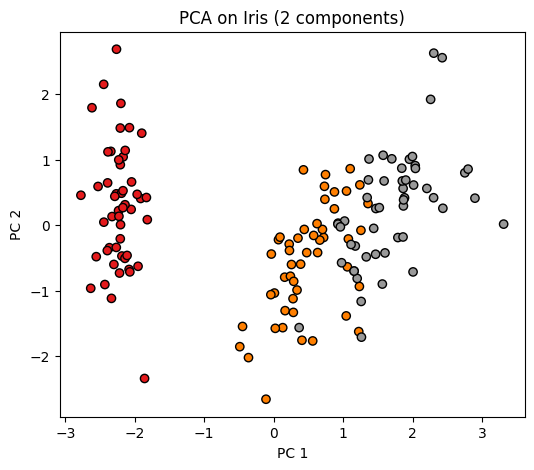

In [7]:

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["target"], cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA on Iris (2 components)")
plt.show()
